In [1]:
import matplotlib.pyplot as plt
import numpy as np
import csv
from matplotlib.patches import Circle, Rectangle

%matplotlib inline
%config InlineBackend.figure_format='retina'

%load_ext autoreload
%autoreload 2

In [2]:
plt.style.use('default')

params = {'text.usetex' : True,
          'font.size'   : 9,
          'font.family' : 'lmodern',
          'figure.constrained_layout.use' : True,
          }
plt.rcParams.update(params)

plt.rcParams['text.latex.preamble'] =  ' \\usepackage{amsmath} \\usepackage{amssymb}'

cm = 1/2.54  # centimeters in inches

In [3]:
# np.savetxt('circ_aa_theory.out',    aa_theory, delimiter=',')
# np.savetxt('circ_ab_theory.out',    ab_theory, delimiter=',')
# np.savetxt('circ_vcz_theory.out',   theory, delimiter=',')
# np.savetxt('circ_corr_wv_mean.out', corr_wv_mean, delimiter=',')

circ_aa_theory    = np.genfromtxt("./data/circ_aa_theory.txt",    delimiter=",")
circ_ab_theory    = np.genfromtxt("./data/circ_ab_theory.txt",    delimiter=",")
circ_vcz_theory   = np.genfromtxt("./data/circ_vcz_theory.txt",   delimiter=",")
circ_corr_wv_mean = np.genfromtxt("./data/circ_corr_wv_mean.txt", delimiter=",")
circ_r_line = np.genfromtxt("./data/circ_dense_baselines.txt", delimiter=",")
circ_r_dots = np.genfromtxt("./data/circ_baselines.txt", delimiter=",")

rect_aa_theory    = np.genfromtxt("./data/rect_aa_theory.txt",    delimiter=",")
rect_ab_theory    = np.genfromtxt("./data/rect_ab_theory.txt",    delimiter=",")
rect_vcz_theory   = np.genfromtxt("./data/rect_vcz_theory.txt",   delimiter=",")
rect_corr_wv_mean = np.genfromtxt("./data/rect_corr_wv_mean.txt", delimiter=",")
rect_r_line = np.genfromtxt("./data/rect_dense_baselines.txt", delimiter=",")
rect_r_dots = np.genfromtxt("./data/rect_baselines.txt", delimiter=",")

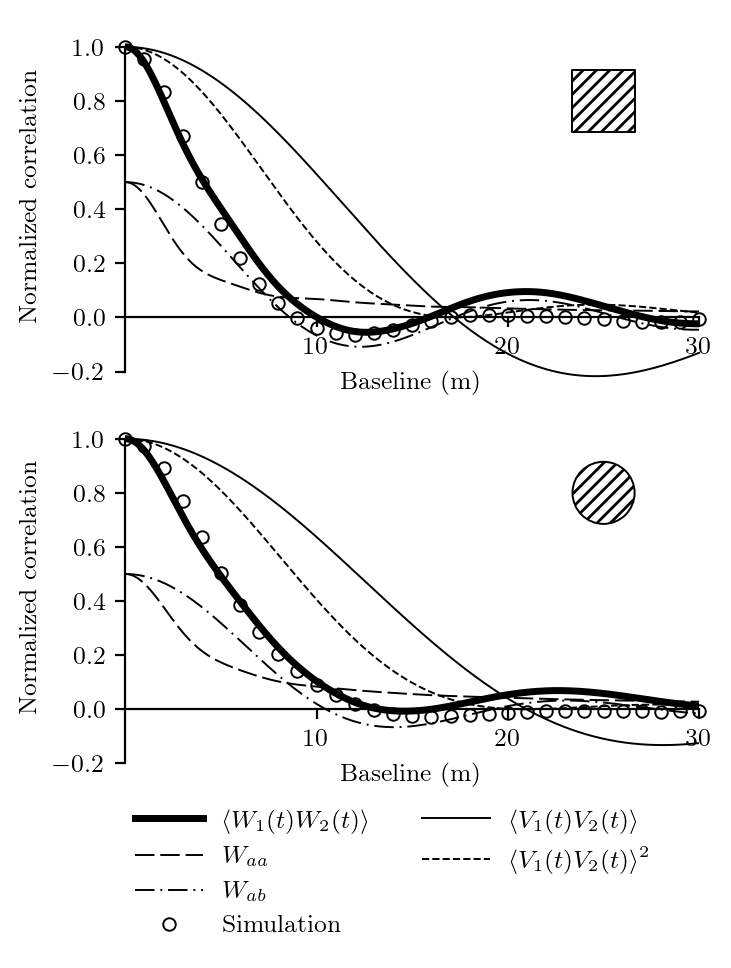

In [4]:
fig, axs = plt.subplots(2, figsize=(9*cm, 12*cm))

res_r_line   = circ_r_line
res_ab       = circ_ab_theory
res_aa       = circ_aa_theory
res_vcz      = circ_vcz_theory
res_dots_sim = circ_r_dots
res_wv_sim   = circ_corr_wv_mean

axN = 1
# N = res_ab[axN] + res_aa[axN]
N = res_ab[0] + res_aa[0]
axs[axN].plot(res_r_line, (res_ab + res_aa)/N, label=r'$\langle W_1(t) W_2(t)\rangle$', ls='-', c='black', lw=2.5)
axs[axN].plot(res_r_line, res_aa/N, ls=(0, (10, 3)), c='black', lw=0.7, label=r'$W_{aa}$')
axs[axN].plot(res_r_line, res_ab/N, ls=(0, (10, 3, 1, 3)), c='black', lw=0.7, label=r'$W_{ab}$')

axs[axN].plot(res_dots_sim, res_wv_sim, 'o', markersize=4.5, markerfacecolor='none', markeredgewidth=0.7, markeredgecolor='black', label='Simulation', clip_on=False)

axs[axN].plot(res_r_line, res_vcz, c='black', lw=0.7, ls='-', label=r'$\langle V_1(t) V_2(t)\rangle$')
axs[axN].plot(res_r_line, res_vcz*res_vcz, c='black', lw=0.7, ls='--', label=r'$\langle V_1(t) V_2(t)\rangle^2$')

axs[axN].set_xlabel(r'Baseline (m)')
axs[axN].set_ylabel(r'Normalized correlation')
axs[axN].spines[['top', 'right']].set_visible(False)
axs[axN].spines[['bottom']].set_position('zero')

axs[axN].set_xticks([10, 20, 30])
axs[axN].set_xlim(0., 30.)
axs[axN].set_yticks([-0.2, 0.0, 0.2, 0.4, 0.6, 0.8, 1.0])
axs[axN].set_ylim(-0.2, 1.1)
axs[axN].spines['left'].set_bounds(-0.2, 1.0)

axs[axN].scatter(25.0, 0.8, s=500, marker='o', edgecolor='black', linewidth=0.7, facecolor='none', hatch='/////')

##########################################################

res_r_line   = rect_r_line
res_ab       = rect_ab_theory
res_aa       = rect_aa_theory
res_vcz      = rect_vcz_theory ##/rect_vcz_theory[0]
res_dots_sim = rect_r_dots
res_wv_sim   = rect_corr_wv_mean

axN = 0
# N = res_ab[axN] + res_aa[axN]
N = res_ab[0] + res_aa[0]
axs[axN].plot(res_r_line, (res_ab + res_aa)/N, label=r'$\langle W_1(t) W_2(t)\rangle$', ls='-', c='black', lw=2.5)
axs[axN].plot(res_r_line, res_aa/N, ls=(0, (10, 3)), c='black', lw=0.7, label=r'$W_{aa}$')
axs[axN].plot(res_r_line, res_ab/N, ls=(0, (10, 3, 1, 3)), c='black', lw=0.7, label=r'$W_{ab}$')

axs[axN].plot(res_dots_sim, res_wv_sim, 'o', markersize=4.5, markerfacecolor='none', markeredgewidth=0.7, markeredgecolor='black', label='Simulation', clip_on=False)

axs[axN].plot(res_r_line, res_vcz, c='black', lw=0.7, ls='-', label=r'$\langle V_1(t) V_2(t)\rangle$', clip_on=False)
axs[axN].plot(res_r_line, res_vcz*res_vcz, c='black', lw=0.7, ls='--', label=r'$\langle V_1(t) V_2(t)\rangle^2$', clip_on=False)

axs[axN].set_xlabel(r'Baseline (m)')
axs[axN].set_ylabel(r'Normalized correlation')
axs[axN].spines[['top', 'right']].set_visible(False)
axs[axN].spines[['bottom']].set_position('zero')

axs[axN].set_xticks([10, 20, 30])
axs[axN].set_xlim(0., 30.)
axs[axN].set_yticks([-0.2, 0.0, 0.2, 0.4, 0.6, 0.8, 1.0])
axs[axN].set_ylim(-0.2, 1.1)
axs[axN].spines['left'].set_bounds(-0.2, 1.0)

axs[axN].scatter(25.0, 0.8, s=500, marker='s', edgecolor='black', linewidth=0.7, facecolor='none', hatch='/////')

##########################################################

# dummy item to make the legend look better
axs[1].scatter(0, 0, s=0, marker='s', edgecolor='none', linewidth=0, facecolor='none', label=' ')
axs[1].legend(frameon=False, bbox_to_anchor=(0.0, -0.10), loc='upper left', borderaxespad=0., ncols=2, handlelength=2.7)

plt.savefig('comb-fig.pdf',  dpi=300)
plt.show()